## **PHÂN TÍCH LUẬT TƯƠNG PHẢN**
**Mục tiêu:**
Áp dụng khai phá luật kết hợp (Rule Association) để tìm quy luật sao cho:
- Xuất hiện nhiều ở các đặc trưng mã độc (Attack)
- Hiếm gặp ở các đặc trưng không phải mã độc (Benign).

## **1. Chuẩn bị vấn đề**

### 1.1. Import các thư viện cần thiết

In [1]:
import gc
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import KBinsDiscretizer

from mlxtend.frequent_patterns import (
    fpgrowth,
    association_rules
)


### 1.2. Tải dữ liệu

In [2]:
df = pd.read_parquet(
    "../data_processed/cleaned_data.parquet"
)

df.columns = [
    c.strip().lower()
    for c in df.columns
]


### 1.3. Chọn các features

In [3]:
features = [
    "network_packet_size",
    "protocol_type",
    "login_attempts",
    "session_duration",
    "encryption_used",
    "ip_reputation_score",
    "failed_logins",
    "browser_type",
    "unusual_time_access"
]

target = "attack_detected"

df = df[
    features + [target]
].copy()

df = df.fillna(0)

### 1.4. Rời rạc hóa các biến số

In [4]:
numeric_cols = [
    "network_packet_size",
    "login_attempts",
    "session_duration",
    "ip_reputation_score",
    "failed_logins"
]

valid_numeric = []

for col in numeric_cols:

    if df[col].nunique() > 5:
        valid_numeric.append(col)

disc = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile"
)

X_disc = disc.fit_transform(
    df[valid_numeric]
)

X_disc = pd.DataFrame(
    X_disc,
    columns=valid_numeric
)

## **3. Thực hiện vấn đề**

### 3.1. Xây dựng transactions

In [5]:
transactions = {}

for col in X_disc.columns:

    vals = X_disc[col].values

    transactions[f"{col}_low"] = (
        vals == 0
    ).astype(np.uint8)

    transactions[f"{col}_mid"] = (
        vals == 1
    ).astype(np.uint8)

    transactions[f"{col}_high"] = (
        vals == 2
    ).astype(np.uint8)


categorical_cols = [
    "protocol_type",
    "encryption_used",
    "browser_type"
]

for col in categorical_cols:

    dummies = pd.get_dummies(
        df[col],
        prefix=col,
        dtype=np.uint8
    )

    for dcol in dummies.columns:
        transactions[dcol] = dummies[dcol].values


transactions["unusual_time_access"] = (
    df["unusual_time_access"]
    .astype(np.uint8)
)

transactions["attack_detected"] = (
    df["attack_detected"]
    .astype(np.uint8)
)


transactions = pd.DataFrame(
    transactions,
    dtype=np.uint8
)

print(
    "Transaction shape:",
    transactions.shape
)

Transaction shape: (7571, 27)


### 3.2. Khởi tạo fpgrowth và luật kết hợp

In [6]:
attack_df = transactions[
    transactions["attack_detected"] == 1
].copy()

benign_df = transactions[
    transactions["attack_detected"] == 0
].copy()

print("Attack samples :", len(attack_df))
print("Benign samples :", len(benign_df))

# REMOVE TARGET COLUMN
attack_df = attack_df.drop(
    columns=["attack_detected"]
)

benign_df = benign_df.drop(
    columns=["attack_detected"]
)

# FP-GROWTH ON ATTACK TRAFFIC
freq_attack = fpgrowth(
    attack_df.astype(bool),
    min_support=0.03,
    use_colnames=True
)

print(
    "Attack frequent itemsets:",
    len(freq_attack)
)


Attack samples : 3354
Benign samples : 4217
Attack frequent itemsets: 1601


### 3.3. Xây dựng luật kết hợp

In [7]:
attack_supports = []
benign_supports = []
contrast_scores = []

# PRECOMPUTE BOOLEAN ARRAYS
attack_bool = attack_df.astype(bool)
benign_bool = benign_df.astype(bool)

# COMPUTE SUPPORTS
for itemset in freq_attack["itemsets"]:

    cols = list(itemset)

    # ATTACK SUPPORT
    att_mask = attack_bool[cols].all(axis=1)

    attack_support = (
        att_mask.mean()
    )

    # BENIGN SUPPORT
    ben_mask = benign_bool[cols].all(axis=1)

    benign_support = (
        ben_mask.mean()
    )

    # CONTRAST SCORE
    contrast = (
        attack_support
        /
        (benign_support + 1e-6)
    )

    attack_supports.append(
        attack_support
    )

    benign_supports.append(
        benign_support
    )

    contrast_scores.append(
        contrast
    )

# BUILD CONTRAST TABLE
freq_attack["attack_support"] = (
    attack_supports
)

freq_attack["benign_support"] = (
    benign_supports
)

freq_attack["contrast_score"] = (
    contrast_scores
)

freq_attack["pattern_size"] = (
    freq_attack["itemsets"]
    .apply(len)
)

# 11. FILTER STRONG CONTRAST PATTERNS
contrast_patterns = freq_attack[
    (
        freq_attack["contrast_score"] >= 2.0
    )
    &
    (
        freq_attack["attack_support"] >= 0.05
    )
    &
    (
        freq_attack["pattern_size"] >= 2
    )
].copy()

# SORT
contrast_patterns = contrast_patterns.sort_values(
    by=[
        "contrast_score",
        "attack_support"
    ],
    ascending=False
)

### 3.4. Kiểm tra kết quả

In [8]:
print("TOP CONTRAST PATTERNS:")

cols = [
    "itemsets",
    "attack_support",
    "benign_support",
    "contrast_score",
    "pattern_size"
]

print(
    contrast_patterns[cols]
    .head(30)
)

TOP CONTRAST PATTERNS:
                                               itemsets  attack_support  \
953   frozenset({encryption_used_AES, browser_type_U...        0.056351   
950   frozenset({browser_type_Unknown, protocol_type...        0.055754   
50    frozenset({failed_logins_high, ip_reputation_s...        0.069767   
45    frozenset({failed_logins_high, ip_reputation_s...        0.093620   
1050  frozenset({failed_logins_high, protocol_type_T...        0.067979   
66    frozenset({browser_type_Chrome, failed_logins_...        0.051282   
1379  frozenset({failed_logins_high, ip_reputation_s...        0.063506   
94    frozenset({ip_reputation_score_high, network_p...        0.061121   
52    frozenset({browser_type_Chrome, failed_logins_...        0.050686   
98    frozenset({network_packet_size_high, failed_lo...        0.057543   
1376  frozenset({ip_reputation_score_high, login_att...        0.063208   
68    frozenset({login_attempts_high, ip_reputation_...        0.051580   
51

### 3.5. Biểu diễn luật qua đồ thị

INTERPRETATION EXAMPLES: 
PATTERN:

   - encryption_used_AES
   - browser_type_Unknown

Metrics:
Attack support  : 0.0564
Benign support  : 0.0171
Contrast score  : 3.30


PATTERN:

   - browser_type_Unknown
   - protocol_type_TCP

Metrics:
Attack support  : 0.0558
Benign support  : 0.0175
Contrast score  : 3.18


PATTERN:

   - failed_logins_high
   - ip_reputation_score_high
   - protocol_type_TCP
   - login_attempts_high

Metrics:
Attack support  : 0.0698
Benign support  : 0.0221
Contrast score  : 3.16


PATTERN:

   - failed_logins_high
   - ip_reputation_score_high
   - login_attempts_high

Metrics:
Attack support  : 0.0936
Benign support  : 0.0306
Contrast score  : 3.06


PATTERN:

   - failed_logins_high
   - protocol_type_TCP
   - network_packet_size_low
   - login_attempts_high

Metrics:
Attack support  : 0.0680
Benign support  : 0.0230
Contrast score  : 2.96




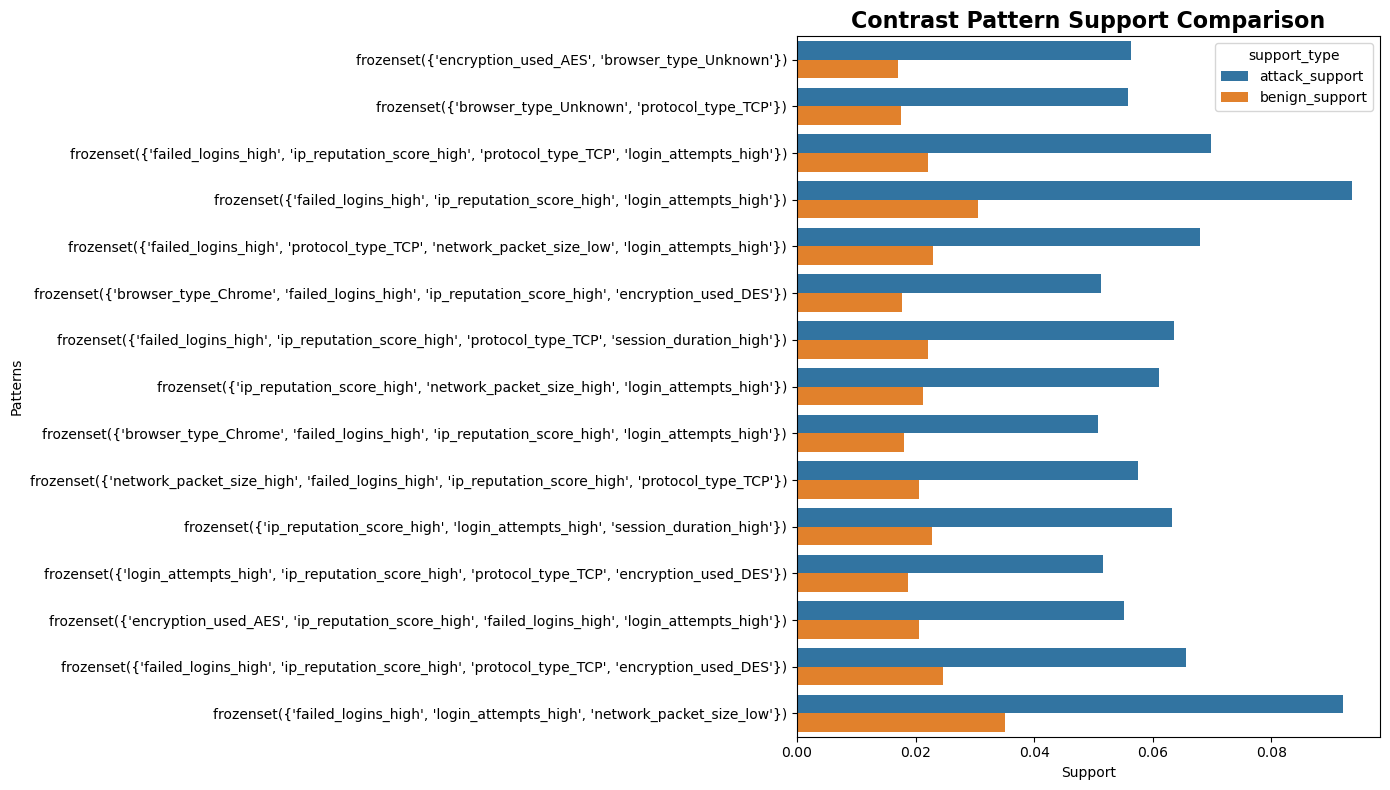

In [ ]:
print("INTERPRETATION EXAMPLES: ")

for _, row in contrast_patterns.head(5).iterrows():

    print("PATTERN:\n")

    for item in row["itemsets"]:
        print(f"   - {item}")

    print("\nMetrics:")
    print(
        f"Attack support  : "
        f"{row['attack_support']:.4f}"
    )

    print(
        f"Benign support  : "
        f"{row['benign_support']:.4f}"
    )

    print(
        f"Contrast score  : "
        f"{row['contrast_score']:.2f}"
    )

    print("\n" + "=" * 50 + "\n")


plot_df = contrast_patterns.head(15).copy()

plot_df["pattern"] = (
    plot_df["itemsets"]
    .astype(str)
)

plot_df = plot_df.melt(
    id_vars="pattern",
    value_vars=[
        "attack_support",
        "benign_support"
    ],
    var_name="support_type",
    value_name="support_value"
)

plt.figure(figsize=(14, 8))

sns.barplot(
    data=plot_df,
    x="support_value",
    y="pattern",
    hue="support_type"
)

plt.title(
    "Contrast Pattern Support Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Support")
plt.ylabel("Patterns")

plt.tight_layout()


plt.show()


# **Kết thúc**